Title: Daily Temperature Forecasting using Layered LSTM

import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import warnings
warnings.filterwarnings('ignore')

load data set

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

df = pd.read_csv(url)

df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


clean data set

In [4]:
data = df['Temp'].values

data = data.reshape(-1,1)

scale data

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data = scaler.fit_transform(data)

print(data[:5])

[[0.78707224]
 [0.68060837]
 [0.7148289 ]
 [0.55513308]
 [0.60076046]]


create sequences

In [6]:
X = []
y = []

for i in range(5, len(data)):
    X.append(data[i-5:i, 0])
    y.append(data[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)
print(y.shape)

(3645, 5, 1)
(3645,)


train-test split

In [7]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2916
Testing samples: 729


build layerd LSTM

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(5,1)
    )
)

model.add(
    LSTM(50)
)

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Train model

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0285 - val_loss: 0.0117
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0128 - val_loss: 0.0113
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0126 - val_loss: 0.0110
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0126 - val_loss: 0.0104
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0121 - val_loss: 0.0104
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0119 - val_loss: 0.0099
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0115 - val_loss: 0.0093
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0109 - val_loss: 0.0090
Epoch 9/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0103 - val_loss: 0.0083
Epoch 10/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0098 - val_loss: 0.0077


prediction

In [10]:
predictions = model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


Convert back

In [11]:
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

RMSE

In [12]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions
    )
)

print("RMSE =", rmse)

RMSE = 2.30241421823242


graphs

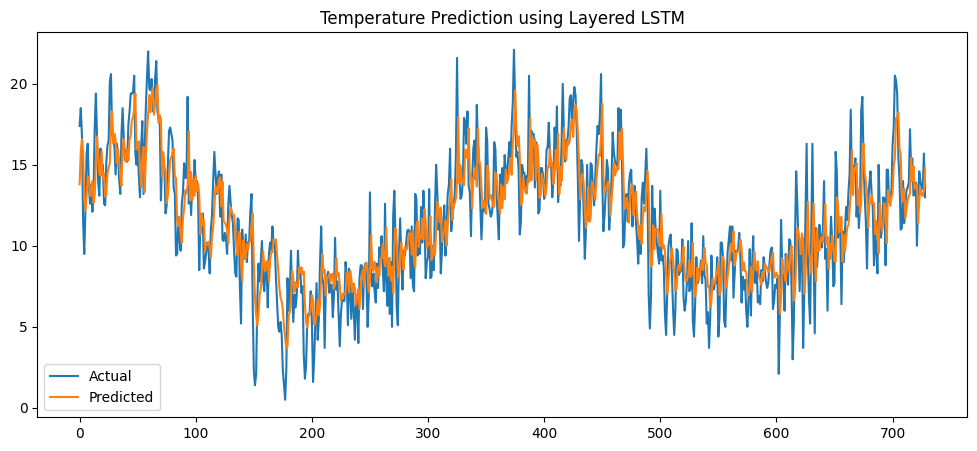

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test_actual, label='Actual')

plt.plot(predictions, label='Predicted')

plt.title("Temperature Prediction using Layered LSTM")

plt.legend()

plt.show()